# 넘파이 함수 없이 hist, cumsum  구현

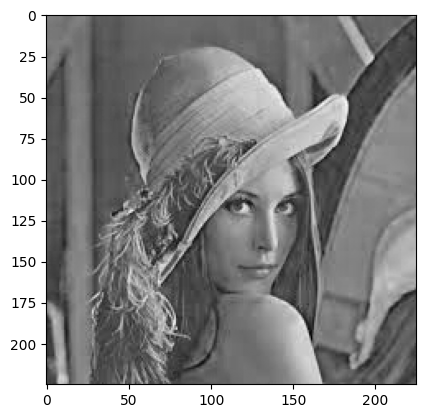

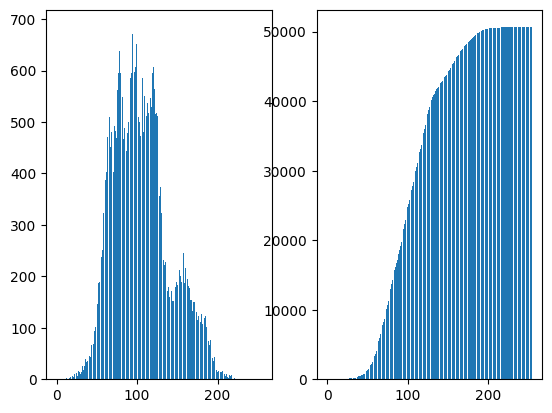

In [2]:
import numpy as np, cv2
import matplotlib.pyplot as plt

src = cv2.imread("images/lenna.jpeg")
src = src[:,:,0]
plt.imshow(src, cmap = 'gray')
plt.show()

# 히스토그램 계산
hist = [0] * 255
bin = range(255)

for y in range(src.shape[0]):
    for x in range(src.shape[1]):
        i = src[y, x]
        hist[i] += 1
        
# 누적값 계산
hist_sum = [0] * 255
for i in range(1, len(hist)):
    hist_sum[i] = hist[i] + hist_sum[i-1]



plt.subplot(1,2,1)
plt.bar(bin, hist)
plt.subplot(1,2,2)
plt.bar(bin, hist_sum)
plt.show()

# np.histogram, np.cumsum 사용

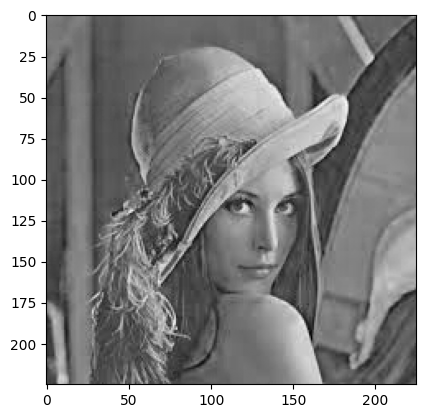

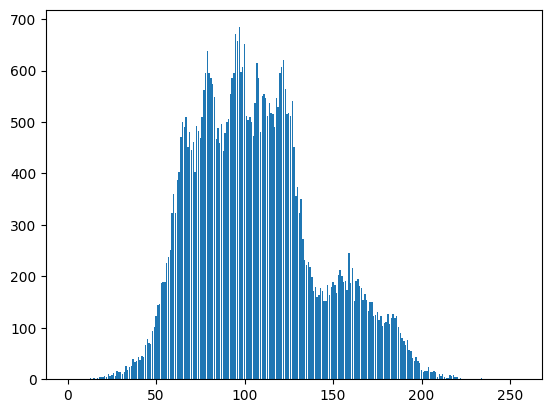

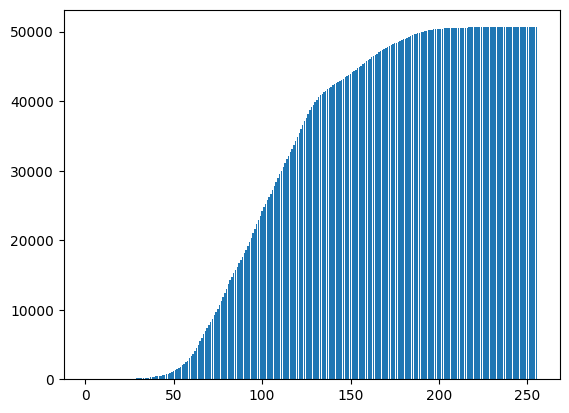

In [3]:
import numpy as np, cv2
import matplotlib.pyplot as plt
img = cv2.imread("images/lenna.jpeg")[:,:, 0]
plt.imshow(img , cmap = "gray")
plt.show() 


hist , bins = np.histogram(img, bins = range(256) )
hist_cum = np.cumsum(hist)

plt.bar(bins[1:], hist)
plt.show()

# bins[1:] 로 값 하나를 제외하는 이유는
# 구간이 이렇게 만들어지고 [0, 1) , [1, 2) ...
# 구간이 255개 이므로 hist 는 255개, 그 구간 경계는 256개 임
# hist 는 255개 bins 는 256 개라 bins 에서 앞이나 뒤 하나는 빼줘야함

plt.bar(bins[1:], hist_cum)
plt.show()

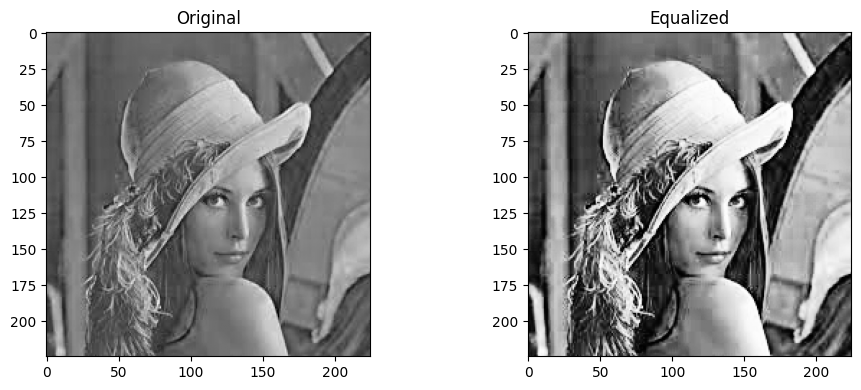

In [4]:
# equalization
img = cv2.imread("images/lenna.jpeg")[:,:, 0]

src = img.copy()

hist , bins = np.histogram(img, bins = range(256) )
hist_cum = np.cumsum(hist)

H = src.shape[0]
W = src.shape[1]

size = H*W


for h in range(H) :
    for w in range(W) :
        pixel_i = src[h][w]
        src[h][w] = int(hist_cum[pixel_i]* (1/size) * 255)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(src, cmap="gray")
plt.title("Equalized")


plt.tight_layout()
plt.show()


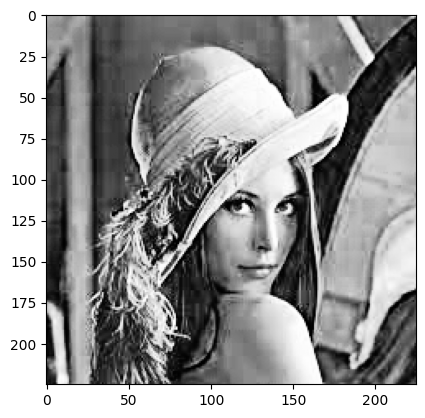

In [5]:
# vectorization and mapping


hist , bins = np.histogram(img, bins = range(256) )
hist_cum = np.cumsum(hist)
src = img.copy()

size = H*W
lut = hist_cum * (1/size) * 255

src_eq = lut[src]
plt.imshow(src_eq, cmap = 'gray')
plt.show()

스트레칭

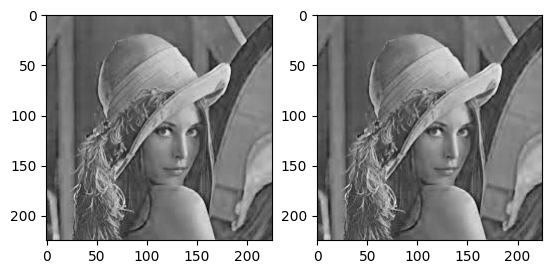

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

src = cv2.imread("images/lenna.jpeg")
src = src[:,:,0]

max_pixel = np.max(src)
min_pixel = np.min(src)
src_stc = ((src - min_pixel)/(max_pixel - min_pixel)) * 255

plt.subplot(1,2,1)
plt.imshow(src, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(src_stc , cmap = 'gray')
plt.show()

Color 이미지 Equalization


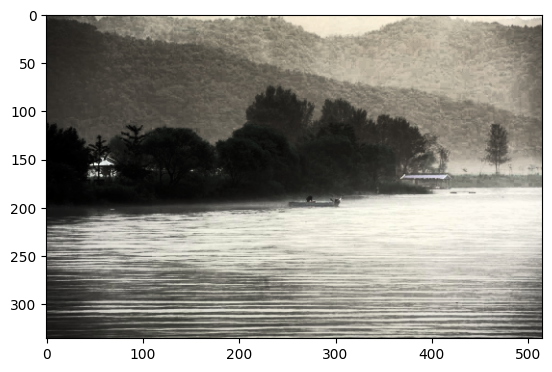

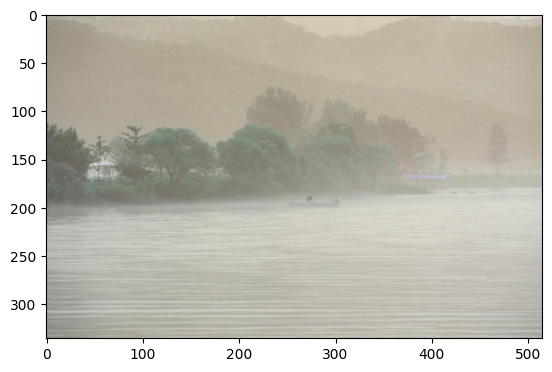

In [7]:

import numpy as np, cv2
import matplotlib.pyplot as plt

# color 이미지 Equalization
src = cv2.imread("images/eq_test1.jpg")

# 1
src_hsv = cv2.cvtColor(src, cv2.COLOR_BGR2HSV)

# 2
V = src_hsv[:,:,2]
V_min = np.min(V)
V_max = np.max(V)

# V_new = ((V - V_min)/(V_max - V_min))*255
V_new = cv2.equalizeHist(V)



# 3
src_hsv[:,:,2] = V_new

# 4
src_rgb = cv2.cvtColor(src_hsv,cv2.COLOR_HSV2BGR)

plt.imshow(src_rgb)
plt.show()

plt.imshow(src)
plt.show()

이진화

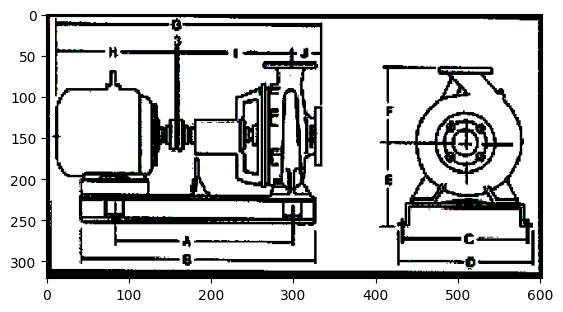

In [8]:
# 이진화

src = cv2.imread("images/binary_test1.jpg")

T = 230

src = np.where(src < T , 0, 255)

plt.imshow(src, cmap='gray')
plt.show()

페이드아웃


In [9]:
import numpy as np, cv2
import matplotlib.pyplot as plt
import cv2

src1 = cv2.imread("images/hillary.jpg")
src2 = cv2.imread("images/woman.jpg")

src2 = cv2.resize(src2, (src1.shape[1], src1.shape[0]))

print(src1.shape)
print(src2.shape)


src1 = src1.astype(float)
src2 = src2.astype(float)

cv2.namedWindow('merged', cv2.WINDOW_AUTOSIZE)
fps = 20
delay = int(1000 / fps)   # cv2.waitKey는 ms 단위
n_figs = 100

n_figs = 100
alpha_lst = np.linspace(0, 1 + 1/n_figs , n_figs)

for alpha in alpha_lst:
    dst = alpha * src1 + (1- alpha)*src2
    dst = np.clip(dst, 0, 255)
    dst = dst.astype(np.uint8)
    cv2.imshow("merged", dst)
    cv2.waitKey(delay)


cv2.destroyAllWindows()






(647, 641, 3)
(647, 641, 3)
